In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
filepath = "data/imports-85.data"
data = pd.read_csv(filepath, header=None)
data.columns = [
    "symboling", "normalized-losses", "make", "fuel-type", "aspiration",
    "num-of-doors", "body-style", "drive-wheels", "engine-location",
    "wheel-base", "length", "width", "height", "curb-weight", "engine-type",
    "num-of-cylinders", "engine-size", "fuel-system", "bore", "stroke",
    "compression-ratio", "horsepower", "peak-rpm", "city-mpg", "highway-mpg",
    "price"]
data['price'] = pd.to_numeric(data['price'], errors='coerce')
data['horsepower'] = pd.to_numeric(data['horsepower'], errors='coerce')
data['normalized-losses'] = pd.to_numeric(data['normalized-losses'], errors='coerce')
#print(data.head())             

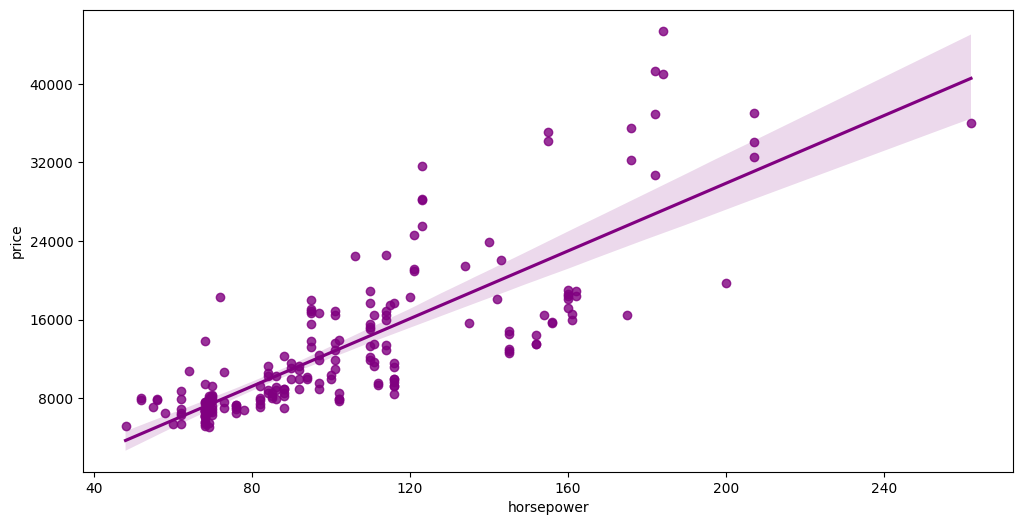

In [4]:
plt.figure(figsize=(12,6))
hp = sns.regplot(data=data, x = "horsepower", y = "price", color='purple')
hp.xaxis.set_major_locator(plt.MaxNLocator(6))
hp.yaxis.set_major_locator(plt.MaxNLocator(6))

Text(0.5, 1.0, 'Car Safety Distribution')

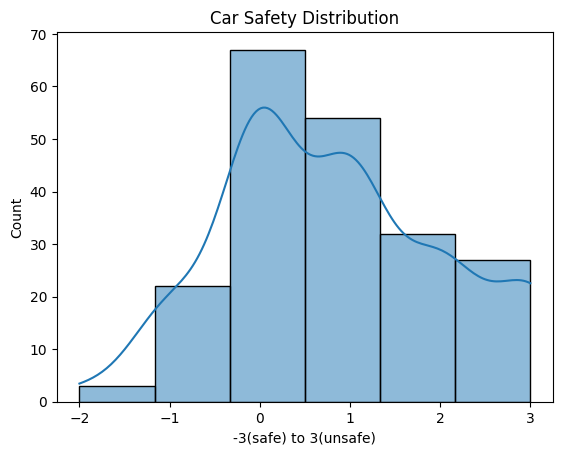

In [5]:
hs = sns.histplot(data=data, x="symboling", bins=6, kde=True)
hs.set_xlabel("-3(safe) to 3(unsafe)")
hs.set_title("Car Safety Distribution")

C:\Users\Donbassenok\AppData\Local\Temp\ipykernel_61136\2708801831.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  bm.set_yticklabels(labels)


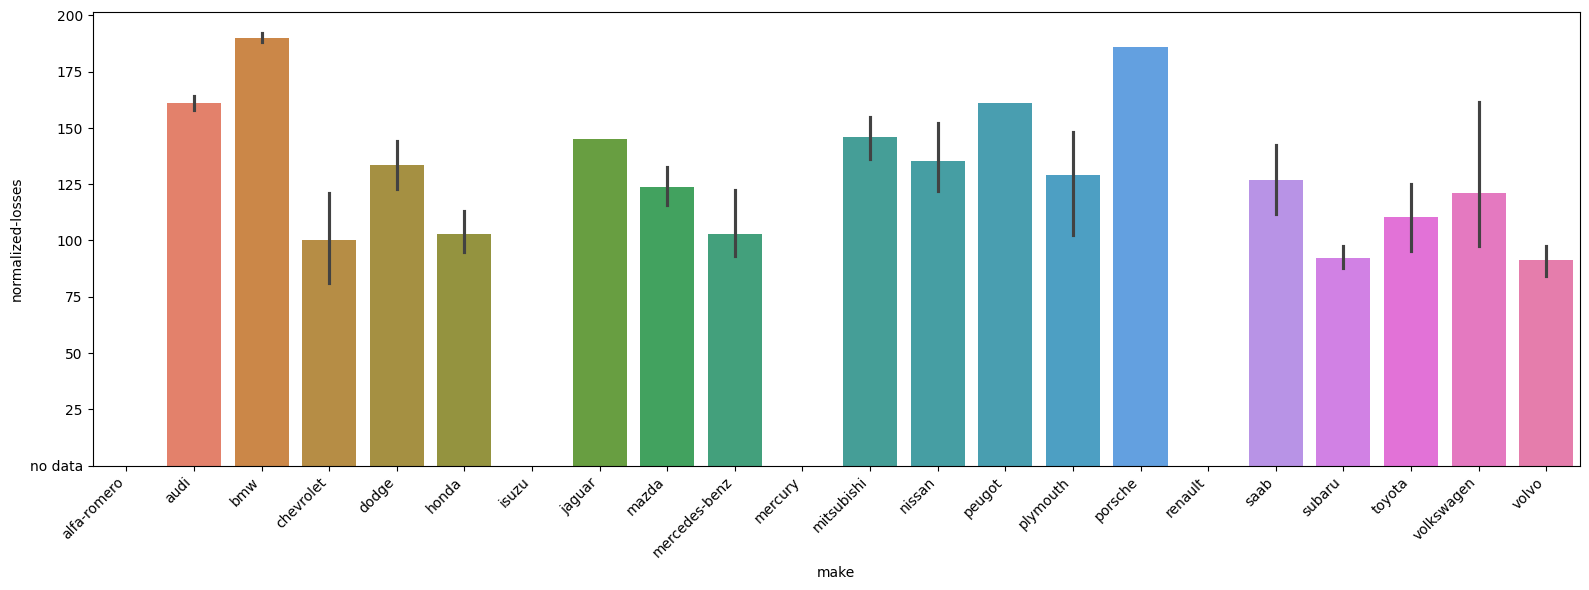

In [ ]:
unique_makes = data['make'].unique()
palette = sns.color_palette("tab20", len(unique_makes))

plt.figure(figsize=(16,6))
bm = sns.barplot(x='make', y='normalized-losses', data=data, order=unique_makes, hue = 'make', legend=False)
plt.xticks(rotation=45, ha='right')
ticks = bm.get_yticks()
labels = [("no data" if t == 0 else f"{t:g}") for t in ticks]
bm.set_yticklabels(labels)
plt.tight_layout()

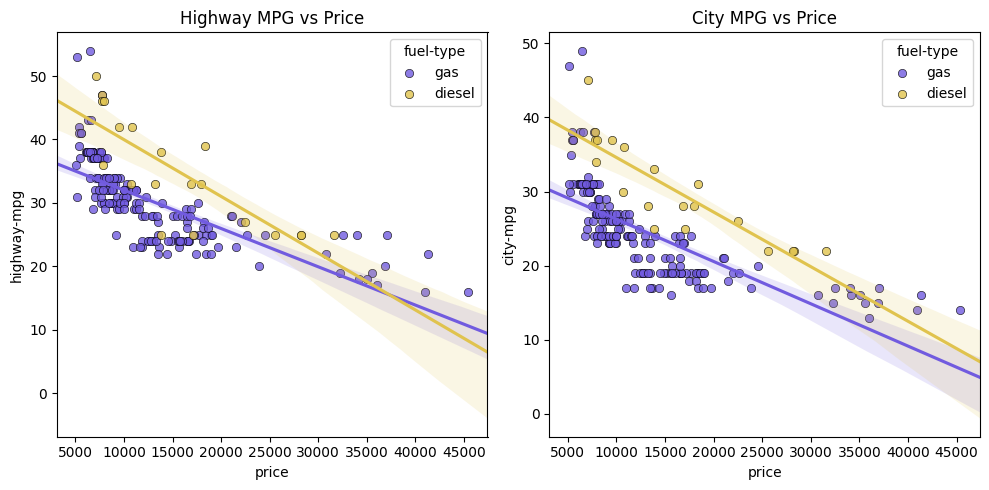

In [7]:
figue, axes = plt.subplots(1, 2, figsize=(10, 5))
palette = {"gas": "#715BDF", "diesel": "#E0C34E"}

for fuel in data['fuel-type'].unique():
    subset = data[data['fuel-type'] == fuel]
    sns.regplot(
        data=subset, x='price', y='highway-mpg',
        ax=axes[0],
        scatter_kws=dict(edgecolor="k", linewidths=0.5),
        line_kws=dict(color=palette.get(fuel)),
        color=palette.get(fuel),
        label=fuel,
        truncate=False
    )
axes[0].set_title('Highway MPG vs Price')
axes[0].legend(title='fuel-type')

for fuel in data['fuel-type'].unique():
    subset = data[data['fuel-type'] == fuel]
    sns.regplot(
        data=subset, x='price', y='city-mpg',
        ax=axes[1],
        scatter_kws=dict(edgecolor="k", linewidths=0.5),
        line_kws=dict(color=palette.get(fuel)),
        color=palette.get(fuel),
        label=fuel,
        truncate=False
    )
axes[1].set_title('City MPG vs Price')
axes[1].legend(title='fuel-type')

plt.tight_layout()

<Axes: xlabel='num-of-doors', ylabel='curb-weight'>

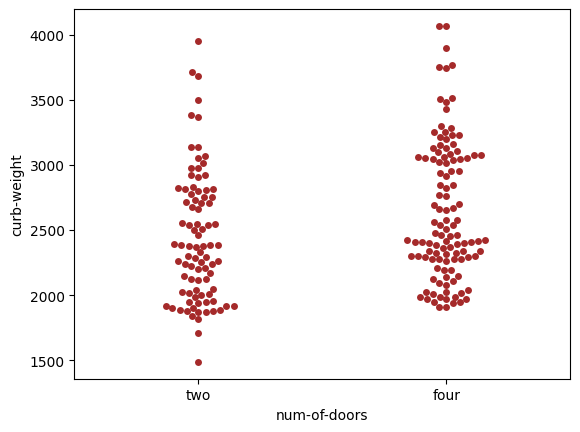

In [8]:
data_filtered = data[data['num-of-doors'] != '?']
sns.swarmplot(x=data_filtered['num-of-doors'],
              y=data_filtered['curb-weight'], color='brown')